In [6]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'

print("Project path:", project_path)
print("Train path:", train_path)
print("Test path:", test_path)

Project path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Train path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/data/raw/archive/data/data/train
Test path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/data/raw/archive/data/data/test


In [8]:
train_files = os.listdir(train_path)

print("Number of training files:", len(train_files))
print("\nFirst 10 files:")
print(train_files[:10])

Number of training files: 82

First 10 files:
['E-13.npy', 'B-1.npy', 'T-9.npy', 'D-7.npy', 'E-11.npy', 'D-2.npy', 'P-14.npy', 'E-3.npy', 'E-7.npy', 'P-7.npy']


In [11]:
import numpy as np

file_path = train_path + '/B-1.npy'

data_B1 = np.load(file_path)

print("Data type:", type(data_B1))
print("Shape:", data_B1.shape)
print("\nFirst 5 rows:")
print(data_B1[:5])

Data type: <class 'numpy.ndarray'>
Shape: (2435, 25)

First 5 rows:
[[-1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [-1.  1.  1.  0.  0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  1.  1.  0.  0.]]


In [12]:
telemetry_B1 = data_B1[:, 0]

print("Telemetry shape:", telemetry_B1.shape)
print("First 20 telemetry values:")
print(telemetry_B1[:20])

Telemetry shape: (2435,)
First 20 telemetry values:
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1.]


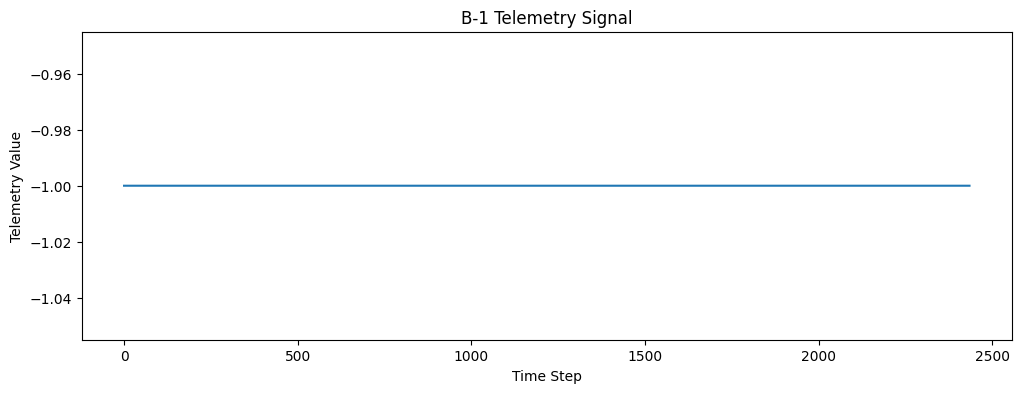

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(telemetry_B1)

plt.title("B-1 Telemetry Signal")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")

plt.show()

In [14]:
data_A1 = np.load(train_path + '/A-1.npy')
telemetry_A1 = data_A1[:, 0]

print("Shape:", telemetry_A1.shape)
print("Minimum:", telemetry_A1.min())
print("Maximum:", telemetry_A1.max())
print("Mean:", telemetry_A1.mean())
print("Standard deviation:", telemetry_A1.std())

Shape: (2880,)
Minimum: 0.999
Maximum: 0.999
Mean: 0.9990000000000001
Standard deviation: 1.1102230246251565e-16


Find channels with variation

In [16]:
import numpy as np
import pandas as pd

channel_stats = []

for filename in train_files:
    data = np.load(train_path + '/' + filename)
    telemetry = data[:, 0]

    channel_stats.append({
        "channel": filename.replace(".npy", ""),
        "min": telemetry.min(),
        "max": telemetry.max(),
        "mean": telemetry.mean(),
        "std": telemetry.std()
    })

stats_df = pd.DataFrame(channel_stats)

stats_df = stats_df.sort_values("std", ascending=False)

print(stats_df.head(10))

   channel       min       max      mean       std
39     A-8 -1.000000  1.000000 -0.246665  0.969045
29     A-9 -1.000000  1.000000  0.240962  0.964619
57     F-5 -1.116378  4.162651 -0.367471  0.900066
20    D-16 -1.000000  1.008880 -0.535443  0.829074
48     E-5 -1.000000  1.000000 -0.586806  0.809728
79    E-12 -1.000000  1.000000 -0.586806  0.809728
18     E-1 -1.000000  1.000000 -0.586806  0.809728
4     E-11 -1.000000  1.000000 -0.587311  0.808742
17    E-10 -1.000000  1.000000 -0.587524  0.808322
47     M-3 -1.477217  1.000071  0.580147  0.727059


Shape: (762,)
Minimum: -1.0
Maximum: 0.9999999999999996
Mean: -0.24666460299358714
Standard deviation: 0.9690446150925986


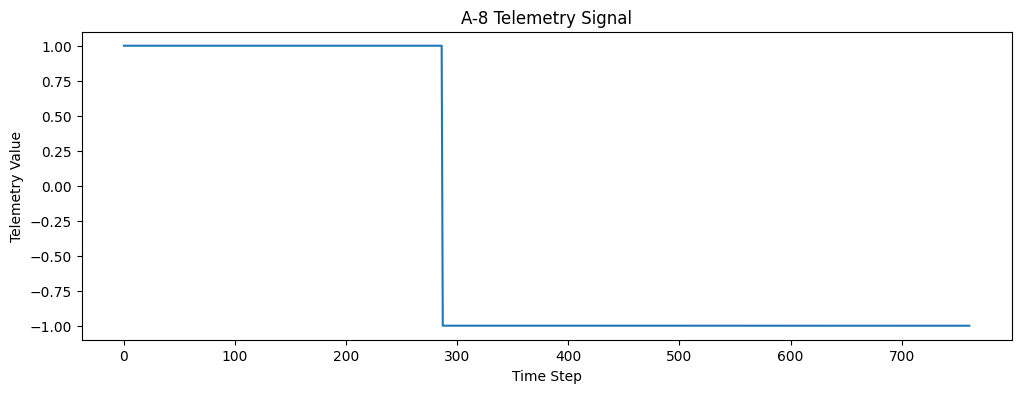

In [17]:
data_A8 = np.load(train_path + '/A-8.npy')
telemetry_A8 = data_A8[:, 0]

print("Shape:", telemetry_A8.shape)
print("Minimum:", telemetry_A8.min())
print("Maximum:", telemetry_A8.max())
print("Mean:", telemetry_A8.mean())
print("Standard deviation:", telemetry_A8.std())

plt.figure(figsize=(12, 4))
plt.plot(telemetry_A8)

plt.title("A-8 Telemetry Signal")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")

plt.show()

In [18]:
labels_path = project_path + '/data/raw/archive/labeled_anomalies.csv'

labels_df = pd.read_csv(labels_path)

print("Shape:", labels_df.shape)
print("\nColumns:")
print(labels_df.columns.tolist())

print("\nFirst 5 rows:")
print(labels_df.head())

Shape: (82, 5)

Columns:
['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values']

First 5 rows:
  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  


In [19]:
a8_info = labels_df[labels_df['chan_id'] == 'A-8']

print(a8_info.to_string(index=False))

chan_id spacecraft anomaly_sequences        class  num_values
    A-8       SMAP    [[4569, 8374]] [contextual]        8375


In [20]:
test_files = os.listdir(test_path)

print("Number of test files:", len(test_files))
print("\nFirst 10 test files:")
print(test_files[:10])

Number of test files: 82

First 10 test files:
['E-1.npy', 'A-4.npy', 'D-6.npy', 'A-2.npy', 'D-7.npy', 'A-1.npy', 'D-12.npy', 'D-1.npy', 'E-3.npy', 'E-2.npy']


In [21]:
train_A8 = np.load(train_path + '/A-8.npy')
test_A8 = np.load(test_path + '/A-8.npy')

print("A-8 train shape:", train_A8.shape)
print("A-8 test shape:", test_A8.shape)

A-8 train shape: (762, 25)
A-8 test shape: (8375, 25)


In [22]:
test_telemetry_A8 = test_A8[:, 0]

print("Test telemetry shape:", test_telemetry_A8.shape)
print("Minimum:", test_telemetry_A8.min())
print("Maximum:", test_telemetry_A8.max())
print("Mean:", test_telemetry_A8.mean())
print("Standard deviation:", test_telemetry_A8.std())

Test telemetry shape: (8375,)
Minimum: -1.0
Maximum: 1.0000000000000002
Mean: -0.5840736581175443
Standard deviation: 0.37660011357148687


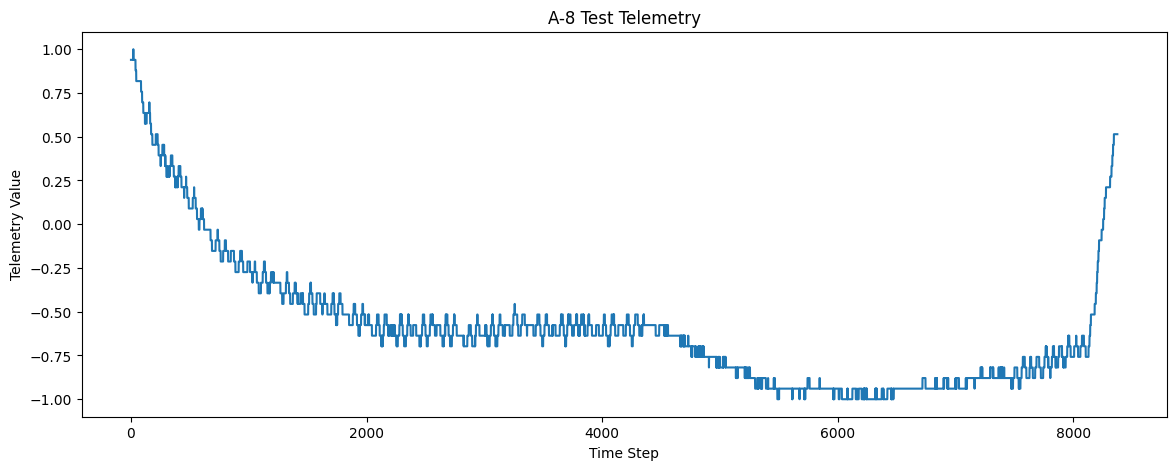

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(test_telemetry_A8)

plt.title("A-8 Test Telemetry")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")

plt.show()

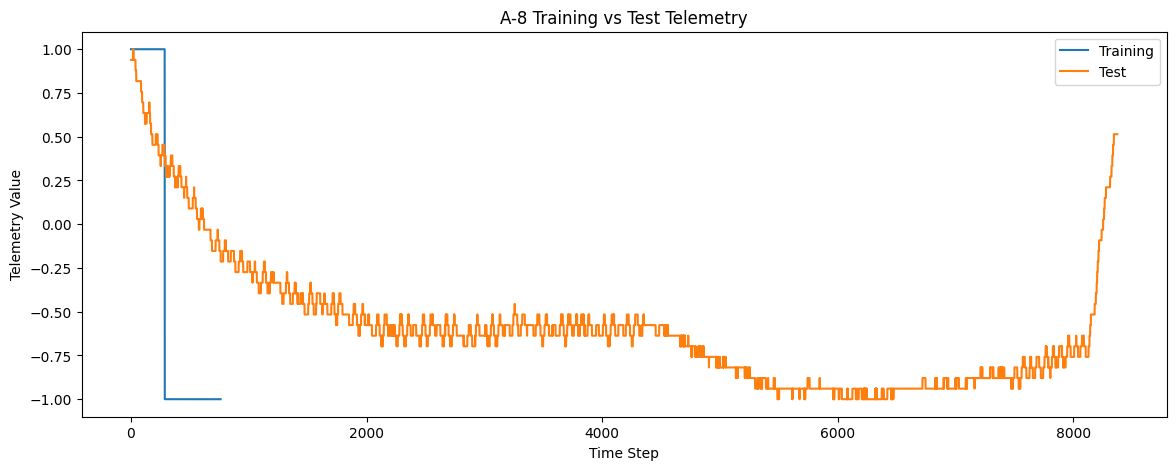

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(telemetry_A8, label="Training")
plt.plot(test_telemetry_A8, label="Test")

plt.title("A-8 Training vs Test Telemetry")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()

plt.show()

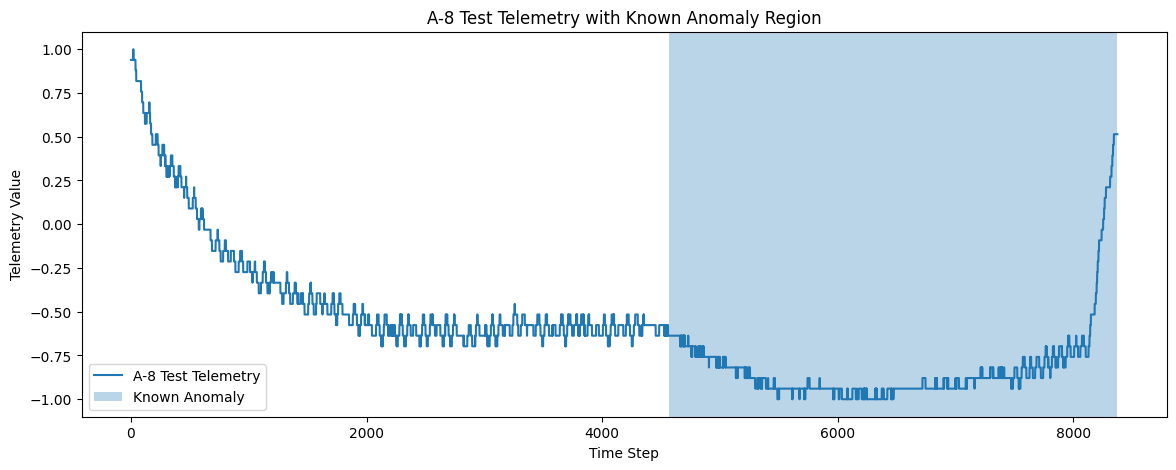

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(test_telemetry_A8, label="A-8 Test Telemetry")

plt.axvspan(4569, 8374, alpha=0.3, label="Known Anomaly")

plt.title("A-8 Test Telemetry with Known Anomaly Region")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()

plt.show()

In [26]:
print("Before anomaly:")
print(test_telemetry_A8[4550:4570])

print("\nDuring anomaly:")
print(test_telemetry_A8[4569:4589])

Before anomaly:
[-0.63696424 -0.63696424 -0.63696424 -0.57643233 -0.63696424 -0.57643233
 -0.57643233 -0.57643233 -0.57643233 -0.57643233 -0.63696424 -0.63696424
 -0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424
 -0.63696424 -0.63696424]

During anomaly:
[-0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424
 -0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424
 -0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424 -0.63696424
 -0.63696424 -0.63696424]


In [27]:
normal_A8 = test_telemetry_A8[:4569]
anomaly_A8 = test_telemetry_A8[4569:8375]

print("Normal region:")
print("Mean:", normal_A8.mean())
print("Std:", normal_A8.std())

print("\nAnomaly region:")
print("Mean:", anomaly_A8.mean())
print("Std:", anomaly_A8.std())

Normal region:
Mean: -0.3906871582666503
Std: 0.35705219656967024

Anomaly region:
Mean: -0.8162289176600386
Std: 0.24546347972239665


In [28]:
anomaly_labels_A8 = np.zeros(len(test_telemetry_A8), dtype=int)

anomaly_labels_A8[4569:8375] = 1

print("Total time steps:", len(anomaly_labels_A8))
print("Normal points:", np.sum(anomaly_labels_A8 == 0))
print("Anomaly points:", np.sum(anomaly_labels_A8 == 1))

Total time steps: 8375
Normal points: 4569
Anomaly points: 3806


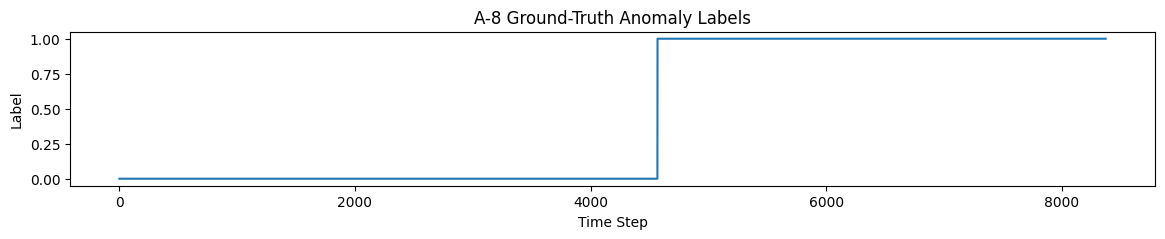

In [29]:
plt.figure(figsize=(14, 2))

plt.plot(anomaly_labels_A8)

plt.title("A-8 Ground-Truth Anomaly Labels")
plt.xlabel("Time Step")
plt.ylabel("Label")

plt.show()

In [30]:
exploration_results = {
    "channel": "A-8",
    "spacecraft": "SMAP",
    "train_shape": train_A8.shape,
    "test_shape": test_A8.shape,
    "anomaly_start": 4569,
    "anomaly_end": 8374,
    "normal_points": 4569,
    "anomaly_points": 3806
}

print("A-8 exploration summary:")
for key, value in exploration_results.items():
    print(f"{key}: {value}")

A-8 exploration summary:
channel: A-8
spacecraft: SMAP
train_shape: (762, 25)
test_shape: (8375, 25)
anomaly_start: 4569
anomaly_end: 8374
normal_points: 4569
anomaly_points: 3806


In [31]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [32]:
!find /content -type d -name ".git" 2>/dev/null

/content/drive/MyDrive/Spacecraft-Anomaly-Detection/.git
/content/drive/.Encrypted/MyDrive/Spacecraft-Anomaly-Detection/.git


In [33]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

/content/drive/MyDrive/Spacecraft-Anomaly-Detection


In [34]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/01_project_setup.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/03_dataset_exploration.ipynb
	notebooks/04_data_visualization.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
